# Cell-1 — Imports, paths & helpers (poly pipeline)

**What this cell does**
- Sets input/output folders.
- Adds safe dtype round-trips (`to_float32`/`from_float32`), natural sorting, preview helpers.
- Implements the *global per-line polynomial fit* used in Algorithm-1/2 of Vo et al. (fit one polynomial for every row/column), and an optional GPU (`cupy`) path. :contentReference[oaicite:2]{index=2}
- Provides `detect_stripe(...)` (Algorithm-4; 1-D robust stripe detector you shared). We’ll use it later to **visualize** suspicious columns/rows (optional).

**Key parameters**
- `global_poly_fit2d(img, axis, polyorder, device)`  
  - `axis`: 0→fit *columns* along rows (good when stripes are **vertical**), 1→fit *rows* along columns (good when stripes are **horizontal**).  
  - `polyorder`: 1–9 typical; start with 3–5 for low-curvature backgrounds.  
  - `device`: `"gpu"` (if CuPy present) or `"cpu"`.

**Tips**
- For **vertical stripes**: `fit_axis=0`, then **smooth along** `axis=1` in Cell-3 (horizontal smoothing suppresses vertical bands).  
- For **horizontal stripes**: `fit_axis=1`, then smooth along `axis=0`.  

**Env note**: Your `imaging-gpu` env already includes CuPy 12.x & SciPy/Scikit-Image; no extra installs. :contentReference[oaicite:3]{index=3}

**Possible pitfalls**
- Very small images with `polyorder ≥ N_points` → we clamp degree to `N−1`. (90%)
- Images with near-zero variation can trip the detector (we guard and warn). (70%)


In [1]:
from __future__ import annotations
import re
from pathlib import Path
from typing import Dict, Any, Sequence, Tuple

import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# ---- Optional GPU stack ----
try:
    import cupy as cp
    CUPY_OK = True
except Exception:
    CUPY_OK = False

# ---------------- Paths & shared state ----------------
DATA_DIR = Path("/home/askiran/data/Normalized_log/_median3d_full/Reslice of _nlm3d")  # change if needed
OUT_DIR  = DATA_DIR / "stripefix_out_poly"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STATE_GP: Dict[str, Any] = dict(
    device="cpu",
    last_path=None,
    last_img=None,
    last_fit=None,
    last_filtered_fit=None,
    last_corrected=None,
    last_axis=0,
    last_meta=None
)

# ---------------- Small helpers ----------------
_num_re = re.compile(r"(\d+)")
def natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in _num_re.split(s)]

def natural_sorted(paths: Sequence[Path]) -> list[Path]:
    return sorted(paths, key=lambda p: natural_key(str(p)))

def list_images(folder: Path) -> list[Path]:
    exts = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")
    return natural_sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

def to_float32(img: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:
    meta = {"dtype": img.dtype}
    if np.issubdtype(img.dtype, np.integer):
        info = np.iinfo(img.dtype)
        meta.update({"imin": info.min, "imax": info.max})
        x = (img.astype(np.float32) - info.min) / max(1.0, (info.max - info.min))
    elif np.issubdtype(img.dtype, np.floating):
        x = img.astype(np.float32, copy=False)
        meta.update({"imin": None, "imax": None})
    else:
        raise TypeError(f"Unsupported dtype: {img.dtype}")
    return x, meta

def from_float32(x: np.ndarray, meta: Dict[str, Any]) -> np.ndarray:
    dtype = meta["dtype"]
    if np.issubdtype(dtype, np.integer):
        imin, imax = meta["imin"], meta["imax"]
        y = np.clip(x, 0.0, 1.0) * (imax - imin) + imin
        return np.rint(y).astype(dtype)
    elif np.issubdtype(dtype, np.floating):
        return x.astype(dtype, copy=False)
    else:
        raise TypeError(f"Unsupported dtype: {dtype}")

def imread_gray(path: Path) -> Tuple[np.ndarray, Dict[str, Any]]:
    arr = iio.imread(path)
    if arr.ndim == 3:  # RGB/RGBA → gray
        if arr.shape[-1] in (3, 4):
            arr = (0.2126*arr[...,0] + 0.7152*arr[...,1] + 0.0722*arr[...,2]).astype(arr.dtype)
        else:
            arr = arr[...,0]
    x, meta = to_float32(arr)
    return x, meta

def imsave_roundtrip(path: Path, x_float: np.ndarray, meta: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(path, from_float32(x_float, meta))

def quick_stats(x: np.ndarray) -> Dict[str, float]:
    return dict(shape=tuple(x.shape),
                min=float(np.min(x)), p1=float(np.percentile(x,1)),
                mean=float(np.mean(x)), median=float(np.median(x)),
                p99=float(np.percentile(x,99)), max=float(np.max(x)),
                std=float(np.std(x)))

def safe_divide(a: np.ndarray, b: np.ndarray, eps: float=1e-6) -> np.ndarray:
    return a / (b + eps)

def show_side_by_side(a: np.ndarray, b: np.ndarray, titles=("A","B"), lock=True):
    if lock:
        both = np.concatenate([a.ravel(), b.ravel()])
        vmin, vmax = np.percentile(both, [1,99])
        vmin, vmax = float(vmin), float(vmax)
        scales = dict(vmin=vmin, vmax=vmax)
    else:
        scales = {}
    fig, axs = plt.subplots(1,2,figsize=(10,5))
    axs[0].imshow(a, cmap="gray", **scales); axs[0].set_title(titles[0]); axs[0].axis("off")
    axs[1].imshow(b, cmap="gray", **scales); axs[1].set_title(titles[1]); axs[1].axis("off")
    plt.show()

# ---------------- Global polynomial fit (stable, no explicit inverse) ----------------
def global_poly_fit2d(img_f32: np.ndarray, axis: int, polyorder: int, device: str="cpu") -> np.ndarray:
    """
    Fit ONE global polynomial per line along `axis`.
      axis=0 → per column (fit along rows)
      axis=1 → per row    (fit along columns)
    Uses least-squares solve (lstsq) for numerical stability.
    """
    d = int(max(0, polyorder))
    use_gpu = (device == "gpu" and CUPY_OK)
    xp = cp if use_gpu else np

    y = xp.asarray(img_f32, dtype=xp.float32)
    if axis == 1:
        y = y.T               # shape (N, M): N points along fit axis, M lines
    N, M = y.shape
    if d >= N:
        d = int(N - 1)        # degree cannot exceed N-1

    # normalized coordinate to reduce conditioning issues
    t = xp.linspace(-1.0, 1.0, N, dtype=xp.float32)
    X = xp.stack([t**k for k in range(d+1)], axis=1)  # (N, d+1)

    # Solve X * B ≈ y  → B has shape (d+1, M)
    if use_gpu:
        B, *_ = cp.linalg.lstsq(X, y, rcond=None)
        yhat = X @ B
        yhat = cp.asnumpy(yhat)
    else:
        B, *_ = np.linalg.lstsq(X, y, rcond=None)
        yhat = X @ B

    if axis == 1:
        yhat = yhat.T
    return np.asarray(yhat, dtype=np.float32)

# --------- Algorithm-4 stripe detector (your function, lightly de-warned) ---------
def detect_stripe(list_data: np.ndarray, snr: float) -> np.ndarray:
    """
    Locate stripe positions using Algorithm 4 (Vo et al., 2018).
    list_data : 1D normalized array
    snr       : >1.0, larger is less sensitive
    Returns   : 1D binary mask (1=stripe)
    """
    npoint = len(list_data)
    list_sort = np.sort(list_data)
    xlist = np.arange(0, npoint, 1.0)
    ndrop = int(0.25 * npoint)
    slope, intercept = np.polyfit(xlist[ndrop:-ndrop - 1],
                                  list_sort[ndrop:-ndrop - 1], 1)[:2]
    y_end = intercept + slope * xlist[-1]
    noise_level = np.abs(y_end - intercept)
    if noise_level < 1.0e-5:
        raise ValueError("Noise-free data not supported by detektor; add noise or normalize differently.")
    val1 = np.abs(list_sort[-1] - y_end) / noise_level
    val2 = np.abs(intercept - list_sort[0]) / noise_level
    list_mask = np.zeros(npoint, dtype=np.float32)
    if val1 >= snr:
        upper_thresh = y_end + noise_level * snr * 0.5
        list_mask[list_data > upper_thresh] = 1.0
    if val2 >= snr:
        lower_thresh = intercept - noise_level * snr * 0.5
        list_mask[list_data <= lower_thresh] = 1.0
    return list_mask
print(f"CUPY_OK = {CUPY_OK}")


CUPY_OK = True


# Cell-2 — Single-image preview + polynomial fit (UI)

**What this cell does**
- Lets you pick an image from `DATA_DIR`.
- Computes `fit = global_poly_fit2d(image, axis, degree, device)`.
- Shows *Original vs Fit* and saves state for later cells.

**Parameters (widgets)**
- **Image**: file selector from `DATA_DIR`.
- **Fit axis**: 0→per column (good for *vertical* stripes), 1→per row (good for *horizontal*).
- **Degree**: polynomial order (start 3–5).
- **Device**: `"gpu"` if available, else `"cpu"`.

**Tuning tips**
- If residuals show wavey over/under-fit, adjust `Degree`.
- If stripes are vertical → *Fit axis=0*; horizontal → *Fit axis=1*.  (See Alg-1/2 idea.) :contentReference[oaicite:4]{index=4}


In [2]:
from ipywidgets import Dropdown, IntSlider, Button, HBox, VBox, HTML, Output

paths = list_images(DATA_DIR)
if not paths:
    raise RuntimeError(f"No images found in {DATA_DIR}")

img_dd = Dropdown(options=[(p.name, p) for p in paths], description="Image:", layout={"width":"400px"})
axis_dd_gp = Dropdown(options=[("columns (axis=0)",0), ("rows (axis=1)",1)], value=0, description="Fit axis:")
deg_sl_gp = IntSlider(value=3, min=1, max=9, step=1, description="Degree:")
dev_dd_gp = Dropdown(options=["cpu"] + (["gpu"] if CUPY_OK else []), value=("gpu" if CUPY_OK else "cpu"), description="Device:")
run_bt = Button(description="Compute fit", button_style="primary")
info = HTML()
out2 = Output()

def _run_fit(_):
    with out2:
        out2.clear_output()
        p = img_dd.value
        img, meta = imread_gray(p)
        fit = global_poly_fit2d(img, axis=int(axis_dd_gp.value), polyorder=int(deg_sl_gp.value), device=str(dev_dd_gp.value))
        STATE_GP.update(last_path=p, last_img=img, last_fit=fit, last_axis=int(axis_dd_gp.value), last_meta=meta, device=str(dev_dd_gp.value))
        s = quick_stats(img)
        print(f"Loaded: {p.name} | shape={s['shape']} | mean={s['mean']:.4f} std={s['std']:.4f}")
        show_side_by_side(img, fit, titles=("Original","Polynomial fit"))

run_bt.on_click(_run_fit)
display(VBox([HBox([img_dd]), HBox([axis_dd_gp, deg_sl_gp, dev_dd_gp, run_bt]), info, out2]))


# Cell-3 — Smooth the fit \hat{I} along one axis

**What this cell does**
- Applies 1-D smoothing to the *fit image* (not the original) to equalize slow drift between neighboring lines—this suppresses stripes while preserving structure (Alg-1/2). :contentReference[oaicite:5]{index=5}
- Filters:
  - **mean** → `uniform_filter` (fast)
  - **median** → `median_filter` (robust to harsh streaks)
  - **gaussian** → `gaussian_filter` (gentle, tunable)

**Parameters**
- **Smooth axis**: 0 or 1 (usually **perpendicular** to the stripe direction; e.g., vertical stripes → smooth axis=1).
- **Filter**: mean / median / gaussian.
- **Window**: odd size (effective length along chosen axis).
- **Show diff**: display (smoothed − fit) panel.

**Common issues**
- Too large window → residual blur/over-equalization. Start with 9–25 and adjust. (80%)


In [5]:
from ipywidgets import Dropdown, RadioButtons, IntSlider, Checkbox, HBox, VBox
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

assert STATE_GP.get("last_fit") is not None, "Run Cell-2 first (compute the polynomial fit)."

# ---- widgets ----
axis_dd = Dropdown(options=[("axis=0",0),("axis=1",1)], value=1, description="Smooth axis:")
ft_dd   = RadioButtons(options=["gaussian","median","mean"], value="gaussian", description="Filter:")
# FIX: no walrus operator; plain integer default
win_sl  = IntSlider(value=9, min=3, max=99, step=2, description="Window")
show_diff_cb = Checkbox(value=True, description="Show difference panel")

out3 = None  # will hold an Output created on first run to avoid stale state

def smooth_1d(A: np.ndarray, axis: int, filter_type: str, win: int) -> np.ndarray:
    win = int(win)
    if win % 2 == 0: win += 1
    if axis == 0:
        size = (win, 1); sigma = (max(win/3.0, 1.0), 0.0)
    else:
        size = (1, win); sigma = (0.0, max(win/3.0, 1.0))
    if filter_type == "mean":
        B = ndi.uniform_filter(A, size=size, mode="nearest")
    elif filter_type == "median":
        B = ndi.median_filter(A, size=size, mode="nearest")
    elif filter_type == "gaussian":
        B = ndi.gaussian_filter(A, sigma=sigma, mode="nearest")
    else:
        raise ValueError("Unknown filter.")
    return B.astype(np.float32, copy=False)

def _run_smooth(*_):
    from ipywidgets import Output  # local import to avoid namespace issues
    global out3
    if out3 is None:
        out3 = Output()
        display(out3)
    with out3:
        out3.clear_output()
        fit0 = STATE_GP["last_fit"].astype(np.float32, copy=False)
        fit1 = smooth_1d(fit0, axis=int(axis_dd.value), filter_type=str(ft_dd.value), win=int(win_sl.value))
        STATE_GP["last_filtered_fit"] = fit1
        titles = ("Fit (before)", "Fit (smoothed)")
        if show_diff_cb.value:
            fig, axs = plt.subplots(1,3,figsize=(15,5))
            both = np.concatenate([fit0.ravel(), fit1.ravel()])
            vmin, vmax = np.percentile(both, [1,99]).astype(float)
            axs[0].imshow(fit0, cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title(titles[0]); axs[0].axis("off")
            axs[1].imshow(fit1, cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title(titles[1]); axs[1].axis("off")
            axs[2].imshow(fit1 - fit0, cmap="gray"); axs[2].set_title("Smoothed − Fit"); axs[2].axis("off")
            plt.show()
        else:
            # shared contrast for side-by-side
            both = np.concatenate([fit0.ravel(), fit1.ravel()])
            vmin, vmax = np.percentile(both, [1,99]).astype(float)
            fig, axs = plt.subplots(1,2,figsize=(10,5))
            axs[0].imshow(fit0, cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title(titles[0]); axs[0].axis("off")
            axs[1].imshow(fit1, cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title(titles[1]); axs[1].axis("off")
            plt.show()

# wire up reactive updates
for w in (axis_dd, ft_dd, win_sl, show_diff_cb):
    w.observe(_run_smooth, names="value")

display(HBox([axis_dd, ft_dd, win_sl, show_diff_cb]))
_run_smooth()


Output()

# Cell-4 — Apply correction and report quality metrics

**What this cell does**
- Applies multiplicative shading fix:  
  \[
  I_{\text{corr}} = \frac{I}{\hat{I}_{\text{poly}} + \varepsilon}\; \cdot \; \hat{I}_{\text{smoothed}}
  \]
  This keeps local contrast while removing line-wise bias (Alg-1/2). :contentReference[oaicite:6]{index=6}
- Computes **SSIM**, **PSNR**, **MSE** (with robust `data_range`).
- *Optional:* builds a quick **1-D stripe mask** (Algorithm-4) from the per-line median of `I / \hat{I}_{poly}` to visualize suspicious lines; useful for tuning.

**Parameters inside cell**
- `snr_mask` (default 3.0): larger → stricter (fewer lines flagged). (Alg-4) :contentReference[oaicite:7]{index=7}

**Failure points**
- If `STATE_GP["last_filtered_fit"]` is missing → run Cell-3. (95%)


SSIM  : 0.878260
PSNR  : 34.406 dB
MSE   : 3.830896e-06
Range : [0.7917, 0.8945]  (data_range=0.1028)


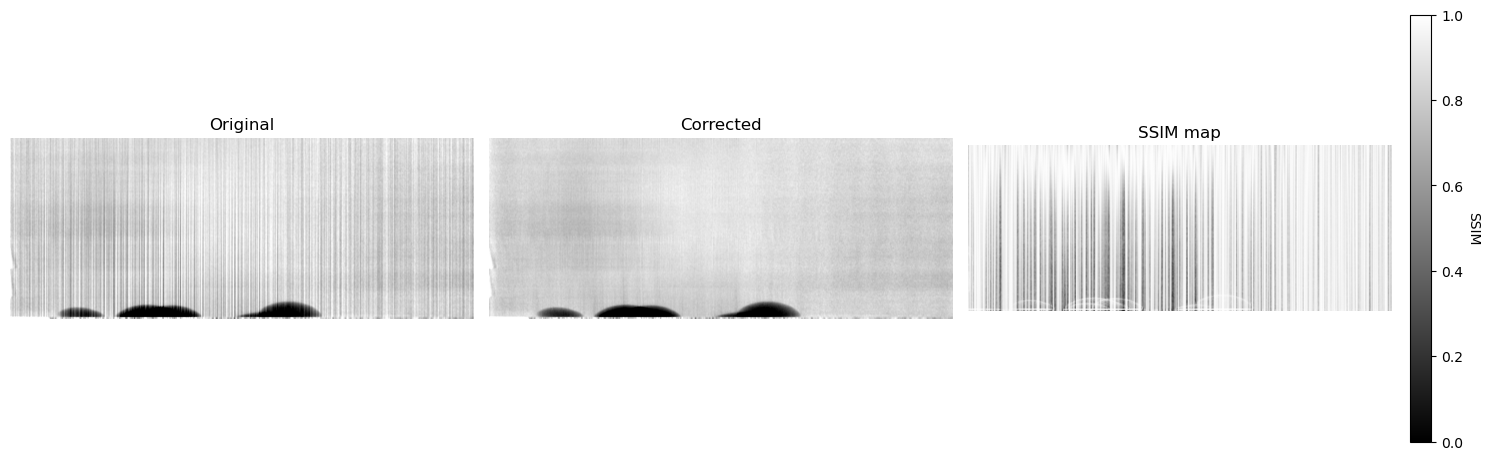

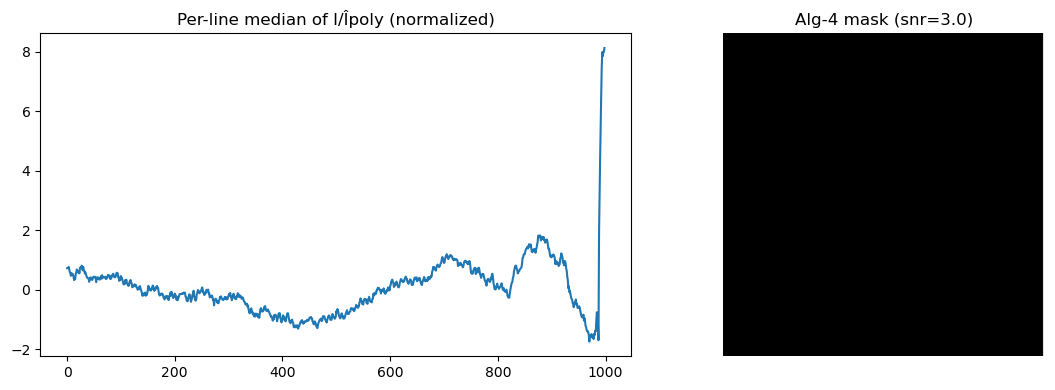

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# pick active state
ACTIVE_STATE = STATE_GP
assert ACTIVE_STATE.get("last_filtered_fit") is not None, "Run Cell-3 to create the smoothed fit."

# metrics
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# grab data
original = ACTIVE_STATE["last_img"].astype(np.float32, copy=False)
fit0     = ACTIVE_STATE["last_fit"].astype(np.float32, copy=False)
fit1     = ACTIVE_STATE["last_filtered_fit"].astype(np.float32, copy=False)

processed = safe_divide(original, fit0) * fit1
ACTIVE_STATE["last_corrected"] = processed

# --- metrics ---
data_min = float(min(original.min(), processed.min()))
data_max = float(max(original.max(), processed.max()))
data_range = data_max - data_min if (data_max > data_min) else 1.0

ssim_val, ssim_map = ssim(original, processed, data_range=data_range, full=True)
psnr_val = psnr(original, processed, data_range=data_range)
mse_val  = mse(original, processed)

print(f"SSIM  : {ssim_val:.6f}")
print(f"PSNR  : {psnr_val:.3f} dB")
print(f"MSE   : {mse_val:.6e}")
print(f"Range : [{data_min:.4f}, {data_max:.4f}]  (data_range={data_range:.4f})")

# --- visualization ---
both = np.concatenate([original.ravel(), processed.ravel()])
vmin, vmax = np.percentile(both, [1, 99]).astype(float)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(original,  cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title("Original");  axs[0].axis("off")
axs[1].imshow(processed, cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title("Corrected"); axs[1].axis("off")
im = axs[2].imshow(ssim_map, cmap="gray", vmin=0.0, vmax=1.0); axs[2].set_title("SSIM map"); axs[2].axis("off")
cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04); cbar.set_label("SSIM", rotation=270, labelpad=12)
plt.tight_layout(); plt.show()

# --- optional: quick 1-D mask using Algorithm-4 to inspect suspicious lines ---
snr_mask = 3.0  # increase if too many lines flagged
axis_used = int(ACTIVE_STATE["last_axis"])
line_stat = np.median(safe_divide(original, fit0), axis=(1-axis_used))  # median per column if axis=0, per row if axis=1
line_stat = (line_stat - np.median(line_stat)) / (np.std(line_stat) + 1e-6)  # normalize
try:
    mask_1d = detect_stripe(line_stat, snr=snr_mask)  # 1 where likely stripe
    mask_img = np.repeat(mask_1d.astype(bool)[None,:], original.shape[0], axis=0) if axis_used==0 else \
               np.repeat(mask_1d.astype(bool)[:,None], original.shape[1], axis=1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(line_stat); plt.title("Per-line median of I/Îpoly (normalized)")
    plt.subplot(1,2,2); plt.imshow(mask_img, cmap="gray"); plt.title(f"Alg-4 mask (snr={snr_mask})"); plt.axis("off")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"[Mask note] Detector skipped: {e}")


# Cell-5 — Batch processing (directory → OUT_DIR)

**What this cell does**
- Runs the exact steps from Cells 2–4 on **every file** in `DATA_DIR`, saving results to `OUT_DIR/`.
- Uses your current parameters:
  - `fit_axis = STATE_GP["last_axis"]`
  - `degree   = deg_sl_gp.value`
  - `device   = dev_dd_gp.value`
  - `smooth_axis = axis_dd.value`, `filter_type = ft_dd.value`, `win_size = win_sl.value`

**Notes**
- GPU is used only for the polynomial fit (if available). Smoothing uses SciPy CPU filters (fast).
- With 16 GB VRAM, images up to ~8k×8k are fine for degree ≤ 9 (the solve is per-line, so VRAM usage is modest).

**Failure points**
- Files with mixed dtypes → round-trip handles it, but verify histograms if contrast appears odd. (80%)
- If any image is 3-channel RGB, we convert to luma before processing. (95%)

**Reference**
- This pipeline implements the “poly-fit + horizontal smoothing + ratio” destriping used in Alg-1/2; Alg-4 is available for diagnostics. :contentReference[oaicite:8]{index=8}


In [7]:
from tqdm import tqdm

# pull current params (with safe fallbacks)
fit_axis   = int(STATE_GP.get("last_axis", 0))
degree     = int(globals().get("deg_sl_gp", type("x",(object,),{"value":3})()).value)
device     = str(globals().get("dev_dd_gp", type("x",(object,),{"value":"cpu"})()).value)

smooth_axis = int(globals().get("axis_dd", type("x",(object,),{"value":0})()).value)
filter_type = str(globals().get("ft_dd",   type("x",(object,),{"value":"gaussian"})()).value)
win_size    = int(globals().get("win_sl",  type("x",(object,),{"value":9})()).value)

def smooth_1d(A: np.ndarray, axis: int, filter_type: str, win: int) -> np.ndarray:
    if win % 2 == 0: win += 1
    if axis == 0:
        size = (win, 1); sigma = (max(win/3.0, 1.0), 0.0)
    else:
        size = (1, win); sigma = (0.0, max(win/3.0, 1.0))
    if filter_type == "mean":
        B = ndi.uniform_filter(A, size=size, mode="nearest")
    elif filter_type == "median":
        B = ndi.median_filter(A, size=size, mode="nearest")
    elif filter_type == "gaussian":
        B = ndi.gaussian_filter(A, sigma=sigma, mode="nearest")
    else:
        raise ValueError("Unknown filter.")
    return B.astype(np.float32, copy=False)

paths = list_images(DATA_DIR)
print(f"Batch: {len(paths)} files | fit_axis={fit_axis}, degree={degree}, device={device} | smoothing: {filter_type}, axis={smooth_axis}, win={win_size}")
for p in tqdm(paths):
    try:
        img, meta = imread_gray(p)
        fit   = global_poly_fit2d(img, axis=fit_axis, polyorder=degree, device=device)
        fit_s = smooth_1d(fit, axis=smooth_axis, filter_type=filter_type, win=win_size)
        corrected = safe_divide(img, fit) * fit_s
        imsave_roundtrip(OUT_DIR / p.name, corrected, meta)
    except Exception as e:
        print(f"[WARN] {p.name}: {e}")
print(f"Done. Saved outputs to: {OUT_DIR}")


Batch: 2160 files | fit_axis=0, degree=2, device=gpu | smoothing: gaussian, axis=1, win=85


100%|████████████████████████████████████████████████████████████████████████████████████████████| 2160/2160 [06:37<00:00,  5.44it/s]

Done. Saved outputs to: /home/askiran/data/Normalized_log/_median3d_full/Reslice of _nlm3d/stripefix_out_poly



# Ideas & Best Practices for **Polynomial Fits** in Destriping

Use this as a reference when tuning your _global polynomial_ baseline in the destriping pipeline.

---
**Per-file pipeline**
1. Read image → float32 (preserve original dtype via metadata).
2. Compute global polynomial **fit** `\hat{I}` with `global_poly_fit2d`.
3. Apply **1D smoothing** to get `\hat{I}_s`.
4. Compute `Corrected = (Original / \hat{I}) * \hat{I}_s`.
5. Save using original dtype.

## When to use a polynomial baseline (vs. Savitzky–Golay)

- **Polynomial (global per line)**: great for **broad, slowly varying bias** across each row/column. Minimal blur because the model is analytic (no window).
- **Savitzky–Golay (local)**: better when the illumination baseline bends locally and you want **windowed** control. It’s a sliding local polynomial, so it smooths more.

**Rule of thumb**  
For camera-line or detector gain differences (classic stripes), start with **global poly** and a **low degree (1–3)**.

---


# Low-order vs High-order Polynomial for Destriping — Which to choose?

- **Start low**: degree **1–2** solves most stripe bias.  
- **Go higher only if the baseline truly curves** along the line; **rarely >3** for destriping.  
- If you feel tempted to go high, first try **1D smoothing on the fit** (Gaussian/median) or **chunked fits** rather than increasing degree.

---

## When **low order** (0–2) is best
- **Typical column/row gain/offset** mismatches (classic vertical/horizontal stripes).  
  - `d=0` (constant): removes a **flat offset** per line.  
  - `d=1` (linear): removes **tilt/gradient** per line.  
  - `d=2` (quadratic): absorbs mild **curvature** from illumination/falloff.
- Datasets where you want **minimal blur** and **no risk of eating structure**.
- Short line lengths (small `N`) → high degrees are numerically shaky and prone to overfit.

**Use cases**
- Flat-fielding residuals in cameras, column amplifier mismatch, CT line artifacts, uniform samples with gentle shading.

---

## When a **higher order** (3–4) might help
- The baseline along each line has **real, broad undulations** (not just noise).  
  Examples: lamp nonuniformity with gentle wiggles, thermal gradients with slow bends.
- Very large `N` (long lines) where a cubic can capture **true** curvature **without touching texture**.

**Caveats**
- Overfitting risk: the fit begins to track **real edges/textures**, which will be divided out → loss of detail.
- Numerical conditioning worsens with degree; prefer **normalized coordinates** `t ∈ [-1,1]` and **least squares (lstsq)**.

---

## When NOT to raise the degree
- When artifacts are more **local/oscillatory** (moire, fine banding): use **Savitzky–Golay** (local) or a **1D Gaussian/median** on the fit instead.
- When the stripe severity **changes along the line**: prefer **chunked polynomials** (segment the line + overlap & blend) rather than a single high-degree global fit.
- When the ratio image `I / Ĩ` is nearly flat already; use a **bigger smoothing window** on the fit, not a higher degree.

---

## Quick chooser
- **Vertical stripes?** Fit per column → `axis=0`.  
- **Horizontal stripes?** Fit per row → `axis=1`.  
- Start with `degree = 1`; if residual curvature remains in the **ratio** (`I/Ĩ`), try `degree = 2` or **smooth the fit** (Gaussian `win=9–31`).  
- Only consider `degree = 3–4` if the baseline clearly bends and smoothing alone can’t handle it.

---

## Degree cheat sheet (by line length & bias shape)
- `N < 64` → **d ≤ 2**  
- `64 ≤ N < 512` → **d = 1–3** (rarely 4)  
- `N ≥ 512` → still **d ≤ 3** for destriping; try chunking before going higher.

---

## Practical signals you picked the right degree
- **Residual** `E = I − Ĩ` looks structure-light (no strong edges captured by the fit).  
- **Ratio** `R = I / Ĩ` is **flat** along the stripe direction (no banding).  
- **SSIM map** (Original vs Corrected) improves in previously striped zones without widespread drops elsewhere.

---

## Safer upgrades than raising degree
- **Robust/weighted LS** (downweight outliers/bright features that cross lines).  
- **Ridge regularization** on coefficients (small λ: `1e-6`–`1e-3`) to tame wiggles.  
- **Chunked polynomials** with overlap + cosine blending.  
- **Orthogonal bases** (Chebyshev/Legendre) if you need d=3–4 robustly.

**Bottom line**: pick the **lowest degree** that flattens `I/Ĩ`. If that’s not enough, **smooth or segment**, don’t keep cranking the polynomial.



## Numerical conditioning

- **Normalize coordinates**: fit on \( t \in [-1,1] \) to reduce ill-conditioning of Vandermonde systems.
- **Use least squares (SVD/`lstsq`)** rather than inverting \(X^TX\).
- **Clamp degree**: \( d \le N-1 \) where \(N\) is line length. With very short lines, keep \(d\le 2\).

**Orthogonal bases (nice-to-have)**  
Instead of powers \(1, t, t^2, \dots\), you can use **Chebyshev** or **Legendre** polynomials in \([-1,1]\) to further stabilize the solve.

---

## Choosing the degree \(d\)

- **Default**: \( d \in \{1, 2, 3\} \).  
  - \(d=1\) (linear) removes tilt/offset per line.  
  - \(d=2\) captures slight curvature.  
  - \(d=3\) for mild undulations.
- **Heuristic by length**:  
  - \(N < 32 \Rightarrow d \le 2\)  
  - \(32 \le N < 256 \Rightarrow d \le 3\)  
  - Larger \(N\) rarely needs \(d>4\) for destriping.
- **Symptoms**  
  - **Underfit** (d too low): stripes remain in the ratio \(I/\hat I\).  
  - **Overfit** (d too high): real textures begin to appear in the fit \(\hat I\) and get “divided out”.

---

## Robust & weighted fitting (if features bias the baseline)

Bright features crossing a line can skew the polynomial. Two options:

- **Masking**: zero-weight known features/ROIs before fitting.
- **IRLS (Iteratively Reweighted Least Squares)**:  
  1. Fit once to get residuals \(r\).  
  2. Compute robust weights \(w = \psi(r/\sigma)/(r/\sigma)\) (e.g., Huber/Tukey).  
  3. Solve **weighted** LS: \((X^\top W X)\beta = X^\top W y\).  
  4. Iterate a few times.

This keeps the baseline driven by the bulk, not outliers.

---

## Light regularization (ridge) to tame wiggles

If \(d \ge 3\) or data are noisy, add a small **ridge** term:
\[
\beta = \arg\min_\beta \|X\beta - y\|_2^2 + \lambda \|\beta\|_2^2
\quad\Rightarrow\quad (X^\top X + \lambda I)\beta = X^\top y
\]
- Start with **\(\lambda \approx 1e\!-\!6\)** to **1e\!-\!3** (on float-scaled data).
- Ridge reduces overfitting without changing the model family.

---

## Chunked / segmented polynomials

If the baseline varies along the **orthogonal** direction too, a single global poly per line may be too rigid.

- Split the image into **chunks** along the **fit axis** (e.g., 2–8 segments vertically if `axis=0`) and fit per chunk.
- Use **overlap + blending** (e.g., cosine weights across overlap) to avoid seams:
  - Fit each chunk independently.  
  - Blend overlapping regions to form a smooth composite baseline.

This mimics “slowly varying” baselines without resorting to windowed filters.

---

## Simple diagnostics you can trust

- **Ratio map**: \( R = I/\hat I \). If stripes remain, they show as banding in \(R\).
- **Residual**: \( E = I - \hat I \). Should be zero-mean, structure-light. If you see textures, degree is too high.
- **Line profiles**: plot a few \(R\) columns/rows. Flat ≈ good.
- **Metrics (Cell-4)**: SSIM/PSNR/MSE between **Original** vs **Corrected**.  
  Expect improved homogeneity but SSIM can drop near edges if over-aggressive.

---


## Extensions if needed

- **2D polynomial surface**: fit one \( f(x,y) \) to the whole image (risks over-smoothing textures).
- **Splines / P-splines**: piecewise polynomials with smoothness penalty (great control, more setup).
- **Monotone/positivity constraints**: specialized solvers if you must enforce shape.

---

## Quick cheat sheet

- **Start**: `axis = 0` (vertical stripes), `degree = 2`, **Gaussian smooth** on fit with `win = 15`, same axis.
- **Stripes persist**: increase to `degree = 3` **or** smooth with bigger `win = 21–31`.
- **Over-correction**: lower `degree` and/or `win`.
- **Features bias fit**: mask features or use robust/weighted LS.
- **Spatially varying baseline**: try **chunked polynomials** with overlap and blending.

_Keep it simple: low degree + gentle 1D smoothing usually wins for destriping._
